# Data Exploration & Preprocessing

Load and analyze the Amazon Reviews 2023 dataset (Books category). Explore file structures, examine sample records, justify field selection, and document preprocessing decisions.

**Sections:**
1. Download data
2. Explore review file
3. Explore metadata file
4. Field selection and justification
5. Text preprocessing decisions

## 1. Download Data

Download Books.jsonl.gz (reviews) and meta_Books.jsonl.gz (metadata) from the official Amazon Reviews 2023 repository. Output: `data/raw/`

In [1]:
import requests
from pathlib import Path
import os
import time

# Get project root (parent of notebooks)
notebook_dir = Path.cwd()
if 'notebooks' in str(notebook_dir):
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

print(f"Project root: {project_root}\n")

# Create required folders at project root
data_raw = project_root / "data" / "raw"
data_processed = project_root / "data" / "processed"
data_raw.mkdir(parents=True, exist_ok=True)
data_processed.mkdir(parents=True, exist_ok=True)

CATEGORY = "Books"

urls = {
    str(data_raw / f"{CATEGORY}.jsonl.gz"): 
        f"https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/{CATEGORY}.jsonl.gz",
    str(data_raw / f"meta_{CATEGORY}.jsonl.gz"): 
        f"https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_{CATEGORY}.jsonl.gz"
}

def format_bytes(bytes_val):
    """Convert bytes to human readable format."""
    for unit in ['B', 'KB', 'MB', 'GB']:
        if bytes_val < 1024:
            return f"{bytes_val:.1f} {unit}"
        bytes_val /= 1024
    return f"{bytes_val:.1f} TB"

print(f"Checking {CATEGORY} files...\n")

for filepath, url in urls.items():
    filename = Path(filepath).name
    
    if Path(filepath).exists():
        size_mb = Path(filepath).stat().st_size / 1024 / 1024
        print(f" Already downloaded: {filename} ({size_mb:.1f} MB)")
        continue
    
    print(f"\nDownloading: {filename}")
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    downloaded = 0
    start_time = time.time()
    
    print(f"Total size: {format_bytes(total_size)}")
    
    with open(filepath, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            downloaded += len(chunk)
            
            if total_size:
                percent = (downloaded / total_size) * 100
                elapsed = time.time() - start_time
                speed = downloaded / elapsed if elapsed > 0 else 0
                
                if speed > 0:
                    remaining_time = (total_size - downloaded) / speed
                    eta_minutes = remaining_time / 60
                    time_str = f"ETA: {eta_minutes:.1f}m"
                else:
                    time_str = "Calculating..."
                
                bar_length = 30
                filled = int(bar_length * downloaded / total_size)
                bar = '█' * filled + '░' * (bar_length - filled)
                
                print(f"  [{bar}] {percent:.1f}% | {format_bytes(downloaded)}/{format_bytes(total_size)} | {time_str}", end='\r')
    
    size_mb = Path(filepath).stat().st_size / 1024 / 1024
    elapsed_time = time.time() - start_time
    avg_speed = format_bytes(Path(filepath).stat().st_size / elapsed_time)
    print(f"\n   Complete: {size_mb:.1f} MB (Speed: {avg_speed}/s)")

print("\n" + "="*60)
print("All files ready!")
print("="*60)

Project root: /Users/esteki/Desktop/MDS/575/test/DSCI_575_project_jchuang_esteki

Checking Books files...


Downloading: Books.jsonl.gz
Total size: 5.8 GB
  [██████████████████████████████] 100.0% | 5.8 GB/5.8 GB | ETA: 0.0m.3m
   Complete: 5928.8 MB (Speed: 1.9 MB/s)

Downloading: meta_Books.jsonl.gz
Total size: 4.6 GB
  [██████████████████████████████] 100.0% | 4.6 GB/4.6 GB | ETA: 0.0m5m
   Complete: 4713.2 MB (Speed: 11.0 MB/s)

All files ready!


## 2. Explore Review File

Load and examine the review file structure (sample of 200 records).

In [6]:
import pandas as pd
from pathlib import Path

notebook_dir = Path.cwd()
project_root = notebook_dir.parent if 'notebooks' in str(notebook_dir) else notebook_dir
data_raw = project_root / "data" / "raw"

CATEGORY = "Books"
REVIEWS_FILE = data_raw / f"{CATEGORY}.jsonl.gz"

print("="*70)
print(f"REVIEW FILE: {CATEGORY}.jsonl.gz")
print("="*70)

df_reviews = pd.read_json(REVIEWS_FILE, lines=True, compression='gzip', nrows=200)

print(f"\nShape: {df_reviews.shape[0]} rows, {df_reviews.shape[1]} columns")
print(f"\nColumns and Types:")
print(df_reviews.dtypes)
print(f"\nMissing Values:")
print(df_reviews.isnull().sum())
print(f"\nSample Records (first 2):")
for idx in range(min(2, len(df_reviews))):
    print(f"\n  Record {idx + 1}:")
    for col in df_reviews.columns:
        val = str(df_reviews.iloc[idx][col])[:80]
        print(f"    {col}: {val}")
print(f"\nRating Distribution:")
print(df_reviews['rating'].value_counts().sort_index())
print(f"\nText Length Statistics:")
text_len = df_reviews['text'].astype(str).str.len()
print(f"  Mean: {text_len.mean():.0f} | Median: {text_len.median():.0f} | Min: {text_len.min():.0f} | Max: {text_len.max():.0f}")

REVIEW FILE: Books.jsonl.gz

Shape: 200 rows, 10 columns

Columns and Types:
rating                        int64
title                           str
text                            str
images                       object
asin                            str
parent_asin                     str
user_id                         str
timestamp            datetime64[ms]
helpful_vote                  int64
verified_purchase              bool
dtype: object

Missing Values:
rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

Sample Records (first 2):

  Record 1:
    rating: 1
    title: Not a watercolor book! Seems like copies imo.
    text: It is definitely not a watercolor book.  The paper bucked completely.  The pages
    images: [{'small_image_url': 'https://m.media-amazon.com/images/I/516HBU7LQoL._SL25

### Visualising the Review Data

The two plots below explore two key properties of the review sample:

- **Rating distribution**: Shows how star ratings are spread across the 200-record sample. A skew toward 5-star ratings is typical of Amazon review data, where satisfied buyers are more likely to leave a review.
- **Review text length**: Shows the character-count distribution of review text. Understanding this spread is important for retrieval — very short reviews carry less semantic signal, while very long ones may dilute the most relevant content when used as document text.

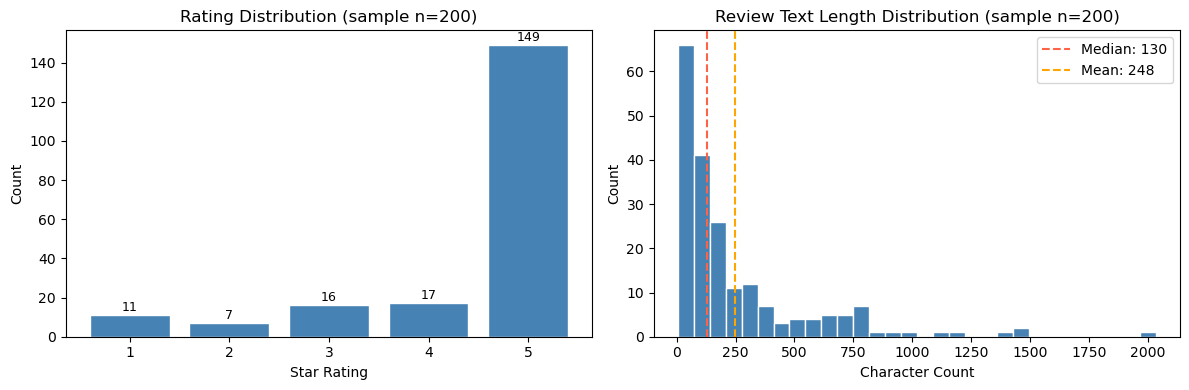

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Rating distribution bar chart
rating_counts = df_reviews['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution (sample n=200)')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
axes[0].set_xticks([1, 2, 3, 4, 5])
for i, (rating, count) in enumerate(rating_counts.items()):
    axes[0].text(rating, count + 0.5, str(count), ha='center', va='bottom', fontsize=9)

# Plot 2: Review text length histogram
text_lengths = df_reviews['text'].astype(str).str.len()
axes[1].hist(text_lengths, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(text_lengths.median(), color='tomato', linestyle='--', label=f'Median: {text_lengths.median():.0f}')
axes[1].axvline(text_lengths.mean(), color='orange', linestyle='--', label=f'Mean: {text_lengths.mean():.0f}')
axes[1].set_title('Review Text Length Distribution (sample n=200)')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Explore Metadata File

Load and examine the metadata file structure (sample of 200 records).

In [8]:
META_FILE = data_raw / f"meta_{CATEGORY}.jsonl.gz"

print("="*70)
print(f"METADATA FILE: meta_{CATEGORY}.jsonl.gz")
print("="*70)

df_meta = pd.read_json(META_FILE, lines=True, compression='gzip', nrows=200)

print(f"\nShape: {df_meta.shape[0]} rows, {df_meta.shape[1]} columns")
print(f"\nAvailable Fields: {list(df_meta.columns)}")
print(f"\nData Types:")
print(df_meta.dtypes)
print(f"\nMissing Values:")
print(df_meta.isnull().sum())
print(f"\nSample Record:")
for col in df_meta.columns:
    val = str(df_meta.iloc[0][col])[:80]
    print(f"  {col}: {val}")

METADATA FILE: meta_Books.jsonl.gz

Shape: 200 rows, 16 columns

Available Fields: ['main_category', 'title', 'subtitle', 'author', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']

Data Types:
main_category          str
title                  str
subtitle               str
author              object
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store                  str
categories          object
details             object
parent_asin            str
bought_together    float64
dtype: object

Missing Values:
main_category        0
title                0
subtitle             9
author              51
average_rating       0
rating_number        0
features             0
description          0
price               10
images               0
vid

### Visualising the Metadata

The two plots below explore data quality and rating characteristics in the metadata sample:

- **Missing values by field**: Shows which metadata fields have incomplete coverage. Fields with high missingness (e.g. `bought_together`, `author`) are poor candidates for retrieval document construction.
- **Average rating distribution**: Shows the spread of per-product average ratings. A strong left skew (most products rated 4–5) is expected and confirms that rating alone is a weak signal for distinguishing product quality.

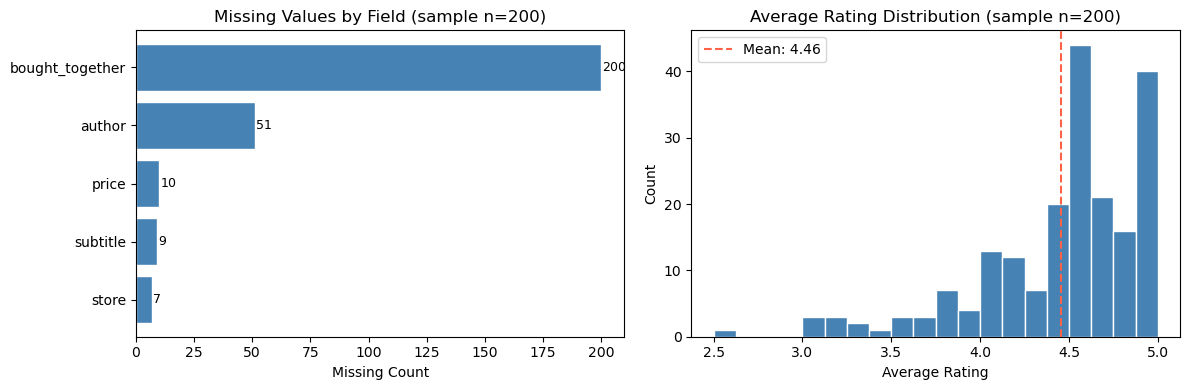

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Missing values per field (only fields with at least one missing)
missing = df_meta.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
axes[0].barh(missing.index, missing.values, color='steelblue', edgecolor='white')
axes[0].set_title('Missing Values by Field (sample n=200)')
axes[0].set_xlabel('Missing Count')
for i, val in enumerate(missing.values):
    axes[0].text(val + 0.5, i, str(val), va='center', fontsize=9)

# Plot 2: Average rating distribution histogram
axes[1].hist(df_meta['average_rating'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(df_meta['average_rating'].mean(), color='tomato', linestyle='--',
                label=f"Mean: {df_meta['average_rating'].mean():.2f}")
axes[1].set_title('Average Rating Distribution (sample n=200)')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Field Selection and Justification

**Review file fields (10 total):** rating, title, text, images, asin, parent_asin, user_id, timestamp, helpful_vote, verified_purchase.

**Metadata file fields (16 total):** main_category, title, subtitle, author, average_rating, rating_number, features, description, price, images, videos, store, categories, details, parent_asin, bought_together.

**Selected fields:** title (product title from metadata) and text (review text from reviews).

**Why selected:** Product title provides exact keywords needed for BM25 keyword matching. Review text provides user context and semantic signal for embedding-based retrieval. Together they support both retrieval approaches.

**Why not selected:** description duplicates title content. author, subtitle, and features are product metadata not relevant to user search intent. rating and price are ranking signals, not retrieval relevance signals. timestamp and user_id contain no content information.

## 5. Text Preprocessing Decisions

**Applied:**
1. Lowercase: Normalizes "iPhone" vs "iphone" variants into single tokens. Reduces vocabulary size.
2. Punctuation removal: Prevents "it's" from splitting into multiple tokens. Improves BM25 matching consistency.
3. Whitespace normalization - Collapses multiple spaces into single spaces. Ensures consistent tokenization.

**Not applied:**
1. Stemming: Reduces vocabulary but harms BM25 recall. Pre-trained embedding models expect standard words, not stemmed forms.
2. Stopword removal: Stopwords carry meaning in reviews ("not good" vs "good" are different). Sentence transformers handle stopwords effectively without removal.